# Digits parameter sweeps

Explore how `IteratedMSTEmbedding` parameters change the digits embedding. The sweep below defaults to the documented MST counts (`1, 2, 4, 8, 16, 32`), uses the same seed for each run, and reports trustworthiness alongside the plots.

The default 500 epochs and larger MST counts can take a few minutes. For a quick iteration, lower `N_EPOCHS` or shorten `VALUES`; restore 500 epochs for a final comparison.

In [1]:
import time
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import load_digits
from sklearn.manifold import trustworthiness
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

from importlib.util import find_spec
from pathlib import Path
import sys

# Make the local package importable when running this notebook from the repo.
if find_spec("mst_embedding") is None:
    project_root = next(
        (parent for parent in (Path.cwd(), *Path.cwd().parents)
         if (parent / "mst_embedding" / "__init__.py").is_file()),
        None,
    )
    if project_root is None:
        raise ModuleNotFoundError(
            "Could not find the mst_embedding package. Run this notebook from "
            "the repository (or install it with `python -m pip install -e .`)."
        )
    sys.path.insert(0, str(project_root))

from mst_embedding import IteratedMSTEmbedding

## Load and scale digits

In [2]:
digits = load_digits()
X = StandardScaler().fit_transform(digits.data)
labels = digits.target

print(f"Samples: {X.shape[0]}, features: {X.shape[1]}")

Samples: 1797, features: 64


## Choose a sweep

Set `PARAMETER` to any estimator parameter, such as `"n_msts"`, `"lambda_rep"`, or `"learning_rate"`, and set `VALUES` to the candidates. `BASE_PARAMS` supplies the remaining estimator settings.

In [3]:
PARAMETER = "n_msts"
VALUES = [1, 2, 4, 8, 16]

BASE_PARAMS = {
    "n_epochs": 500,
    "batch_size": 4096,
    "learning_rate": 0.05,
    "negative_ratio": 4,
    "lambda_rep": 1.0,
    "random_state": 42,
    "epsilon": 1e-4,
}
TRUSTWORTHINESS_NEIGHBORS = 10

Each panel colors samples by their digit label and reports 5-fold cross-validated 5-nearest-neighbor accuracy using the 2D coordinates. Trustworthiness summarizes how well local neighborhoods in the original standardized data are preserved in 2D. Both scores are for comparison only and are not used to train the embedding. The accuracy is a transductive estimate: the embedding was fitted jointly on all unlabeled samples before the classifier folds were evaluated.

Fitting n_msts=1 ...
Finished n_msts=1 in 4 sec
Fitting n_msts=2 ...
Finished n_msts=2 in 5 sec
Fitting n_msts=4 ...
Finished n_msts=4 in 11 sec
Fitting n_msts=8 ...
Finished n_msts=8 in 22 sec
Fitting n_msts=16 ...
Finished n_msts=16 in 43 sec


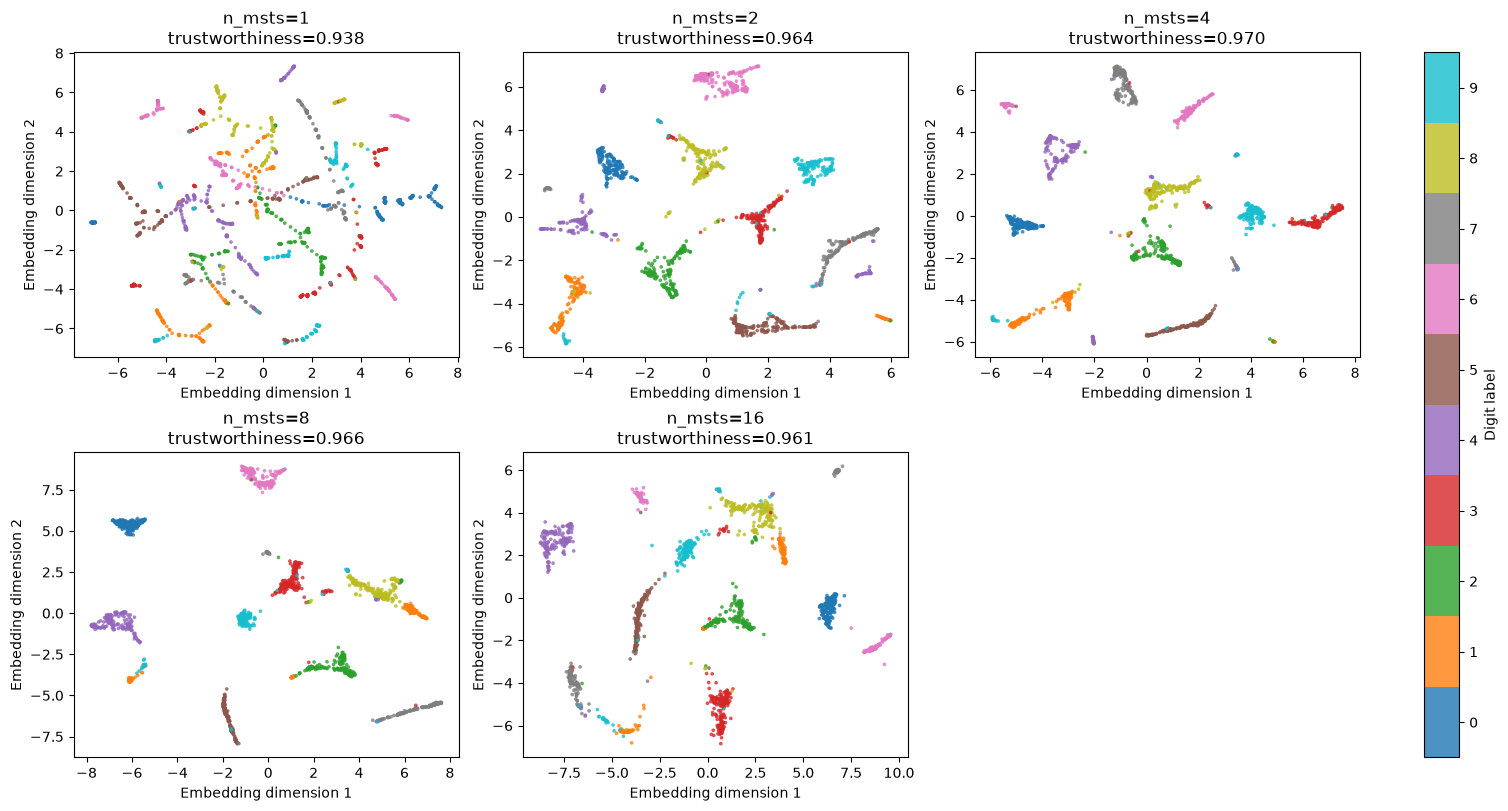

,n_msts,trustworthiness,seconds,elapsed
0,1,0.938325,3.513260,4 sec
1,2,0.963889,5.378688,5 sec
2,4,0.970009,10.753581,11 sec
3,8,0.965716,21.549970,22 sec
4,16,0.960670,42.923570,43 sec


In [4]:
def format_duration(seconds):
    """Format elapsed time using the largest useful units."""
    total_seconds = int(round(seconds))
    hours, remainder = divmod(total_seconds, 3600)
    minutes, seconds = divmod(remainder, 60)
    if hours:
        return f"{hours} hr {minutes} min" if minutes else f"{hours} hr"
    if minutes:
        return f"{minutes} min {seconds} sec"
    return f"{seconds} sec"


def run_sweep(X, labels, parameter, values, base_params, n_neighbors=10):
    """Fit one embedding per parameter value and display a comparison grid."""
    if parameter not in IteratedMSTEmbedding().get_params():
        raise ValueError(f"Unknown estimator parameter: {parameter!r}")
    if not values:
        raise ValueError("values must contain at least one candidate")

    results = []
    ncols = min(3, len(values))
    nrows = math.ceil(len(values) / ncols)
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(5 * ncols, 4 * nrows), squeeze=False,
        constrained_layout=True,
    )

    for index, value in enumerate(values):
        params = dict(base_params)
        params[parameter] = value
        estimator = IteratedMSTEmbedding(**params)
        started = time.perf_counter()
        print(f"Fitting {parameter}={value} ...", flush=True)
        embedding = estimator.fit_transform(X)
        elapsed = time.perf_counter() - started
        print(f"Finished {parameter}={value} in {format_duration(elapsed)}", flush=True)
        score = trustworthiness(
            X, embedding, n_neighbors=min(n_neighbors, len(X) - 1)
        )
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        knn_accuracy = cross_val_score(
            KNeighborsClassifier(n_neighbors=5), embedding, labels, cv=cv
        ).mean()
        results.append({
            parameter: value,
            "trustworthiness": score,
            "5-NN 5-fold CV accuracy": knn_accuracy,
            "seconds": elapsed,
            "elapsed": format_duration(elapsed),
            "embedding": embedding,
        })

        ax = axes.flat[index]
        points = ax.scatter(
            embedding[:, 0], embedding[:, 1], c=labels, cmap="tab10",
            vmin=-0.5, vmax=9.5, s=7, alpha=0.8, linewidths=0,
        )
        ax.set_title(
            f"{parameter}={value}\n"
            f"trustworthiness={score:.3f}\n"
            f"5-NN 5-fold CV accuracy={knn_accuracy:.3f}"
        )
        ax.set_xlabel("Embedding dimension 1")
        ax.set_ylabel("Embedding dimension 2")

    for ax in axes.flat[len(values):]:
        ax.set_visible(False)
    colorbar = fig.colorbar(points, ax=list(axes.flat[:len(values)]), ticks=range(10))
    colorbar.set_label("Digit label")
    plt.show()

    summary = pd.DataFrame(
        [{key: value for key, value in row.items() if key != "embedding"}
         for row in results]
    )
    return results, summary

results, summary = run_sweep(
    X, labels, PARAMETER, VALUES, BASE_PARAMS,
    n_neighbors=TRUSTWORTHINESS_NEIGHBORS,
)
summary

## Inspect one result

The full coordinates are retained in `results`; for example, select an embedding by its sweep index and reuse it in your own plots or downstream analysis.

In [5]:
# Example: first embedding from the sweep
first_embedding = results[0]["embedding"]
first_embedding.shape

(1797, 2)